In [3]:
# 데이터 준비 ( 파일에서 데이터 읽기 )

f = open('data-files/weather_data.csv', 'rt', encoding="utf-8") # 열기 (텍스트파일 읽기)
rows = f.readlines() # readlines : \n 기준으로 나누어서 읽고 리스트로 반환

print(type(rows))
print(len(rows))
print(rows[1])

f.close() # 닫기

<class 'list'>
42017
108,서울,1907-10-01,13.5,20.7,,7.9,,12.8



In [12]:
# 데이터 준비 ( 파일에서 데이터 읽기 )

with open('data-files/weather_data.csv', 'rt', encoding="utf-8") as f: # with 블럭이 끝나면 자동으로 파일 닫기
    rows = f.readlines() # readlines : \n 기준으로 나누어서 읽고 리스트로 반환
    all_data = []
    for idx, row in enumerate(rows[1:]): # enumerate : 순서 번호도 같이 반환
        data = row.split(',')
        # print(data)
        data2 = data[2:5] + data[6:7] + data[8:] # 필요한 데이터만 뽑기 (날짜와 기온 데이터만 뽑기)
        # print(data2)
        data2[-1] = data2[-1].replace('\n', '') # 마지막 데이터에 포함된 '\n' 제거
        # print(data2)
        for idx in range(1, 5):
            if data2[idx] != '':
                data2[idx] = float(data2[idx]) # 문자 -> 숫자
            else:
                break
        else: # 반복문에 대응하는 else : 반복문이 break로 종료되지 않았을 때에만 실행되는 영역
            # print(data2)
            all_data.append(data2)
            # break


In [15]:
print(len(all_data))
all_data[-5:]

41256


[['2023-12-13', 6.8, 10.3, 2.6, 7.7],
 ['2023-12-14', 7.6, 9.1, 6.2, 2.9],
 ['2023-12-15', 4.9, 6.2, 3.7, 2.5],
 ['2023-12-16', -4.1, 3.8, -9.9, 13.7],
 ['2023-12-17', -9.8, -6.4, -12.4, 6.0]]

In [18]:
# 제일 추웠던 날 찾기
data = None
for row in all_data:
    if data == None:
        data = row
    else:
        if data[3] > row[3]: # 이전까지의 최저기온보다 현재 행의 최저기온이 낮다면
            data = row

print(data)

['1927-12-31', -15.3, -6.4, -23.1, 16.7]


In [ ]:
# 제일 더웠던 날 찾기
data = None
for row in all_data:
    if data == None:
        data = row
    else:
        if data[2] < row[2]: # 이전까지의 최고기온보다 현재 행의 최고기온이 높다면
            data = row

print(data)

['2018-08-01', 33.6, 39.6, 27.8, 11.8]


In [19]:
# 일교차가 제일 컸던 날 찾기
data = None
for row in all_data:
    if data == None:
        data = row
    else:
        if data[-1] < row[-1]: # 이전까지의 일교차보다 현재 행의 일교차가 크다면
            data = row

print(data)

['1942-04-19', 12.7, 24.3, 2.5, 21.8]


In [20]:
# 매년 6월 10일 데이터 뽑기

filtered_data = []
for row in all_data:
    if row[0][-5:] == '06-10':
        filtered_data.append(row)

filtered_data

[['1908-06-10', 20.3, 27.5, 14.5, 13.0],
 ['1909-06-10', 18.1, 26.0, 11.2, 14.8],
 ['1910-06-10', 20.0, 26.7, 13.7, 13.0],
 ['1911-06-10', 19.9, 27.8, 13.7, 14.1],
 ['1912-06-10', 17.8, 23.3, 12.7, 10.6],
 ['1913-06-10', 22.0, 26.8, 15.2, 11.6],
 ['1914-06-10', 19.2, 26.0, 14.7, 11.3],
 ['1915-06-10', 22.6, 27.5, 17.8, 9.7],
 ['1916-06-10', 17.1, 21.2, 14.7, 6.5],
 ['1917-06-10', 19.4, 27.3, 13.3, 14.0],
 ['1918-06-10', 16.6, 19.7, 14.5, 5.2],
 ['1919-06-10', 20.8, 25.0, 18.2, 6.8],
 ['1920-06-10', 24.8, 32.0, 17.2, 14.8],
 ['1921-06-10', 20.2, 22.6, 17.7, 4.9],
 ['1922-06-10', 18.3, 22.3, 15.9, 6.4],
 ['1923-06-10', 20.0, 23.7, 17.8, 5.9],
 ['1924-06-10', 18.3, 24.0, 14.0, 10.0],
 ['1925-06-10', 20.6, 25.6, 15.4, 10.2],
 ['1926-06-10', 20.5, 26.8, 14.7, 12.1],
 ['1927-06-10', 21.7, 28.2, 15.6, 12.6],
 ['1928-06-10', 23.8, 31.8, 15.8, 16.0],
 ['1929-06-10', 23.7, 31.0, 16.6, 14.4],
 ['1930-06-10', 20.5, 30.2, 11.5, 18.7],
 ['1931-06-10', 20.3, 25.5, 17.2, 8.3],
 ['1932-06-10', 21.9, 28

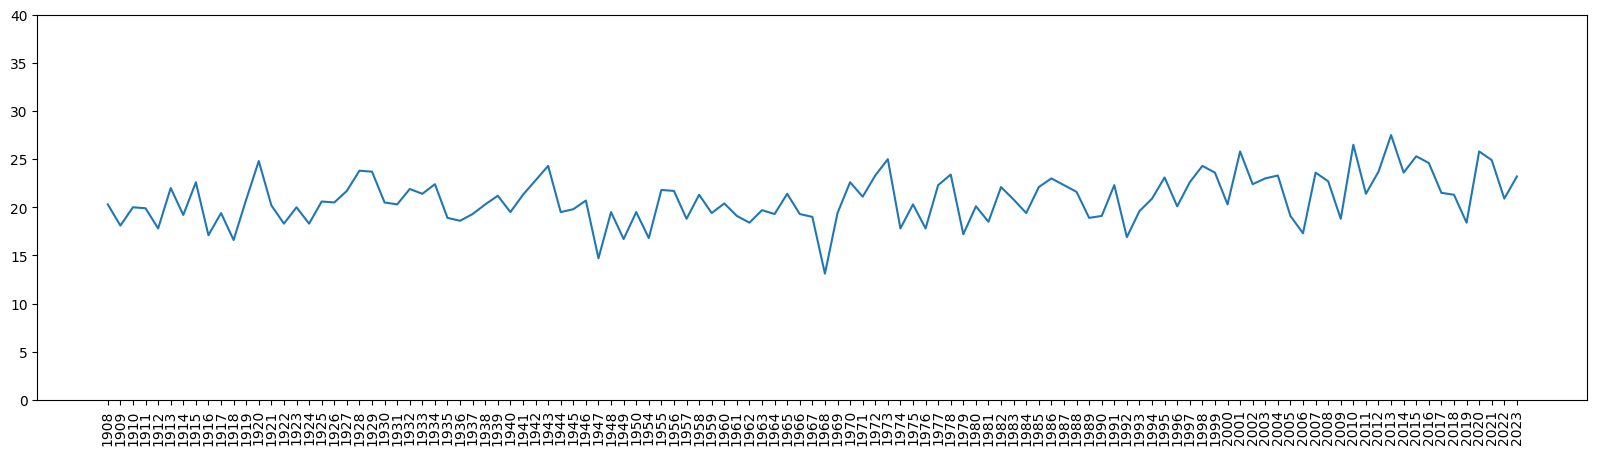

In [31]:
# 시각화 도구(패키지) 준비
import matplotlib.pyplot as plt

avg_temp = []
dates = []
for row in filtered_data:
    avg_temp.append( row[1] )
    dates.append(row[0][:4])

plt.figure(figsize=(20, 5)) # 그래프의 크기 설정
plt.ylim(0, 40)
plt.xticks(rotation=90)
plt.plot(dates, avg_temp) # 선그래프 그리기
plt.show()